# Benchmark 1D 

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam
from time import perf_counter
import tensorflow as tf
from generalization import Neural_network, MultiFidelity

from cuqi.distribution import Uniform, Gaussian,JointDistribution
from cuqi.sampler import MH, NUTS
from cuqi.model import Model
from cuqi.geometry import Continuous1D, Discrete
import keras

# Creation of the model

In [2]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

HPO = False

#Benchmark1
highfid = lambda x: (6.*x-2.)**2*np.sin(12.*x-4.)
lowfid  = lambda x: 0.5*highfid(x) + 10*(x-0.5) + 5.
Nhf = 5
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

NepoLF = 1000
NepoHF = 500

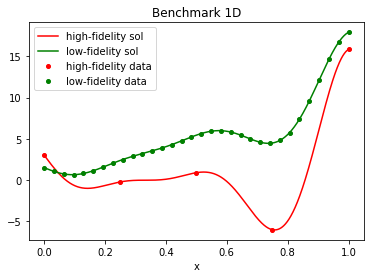

In [3]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [4]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)


## High fidelity model

In [5]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [6]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

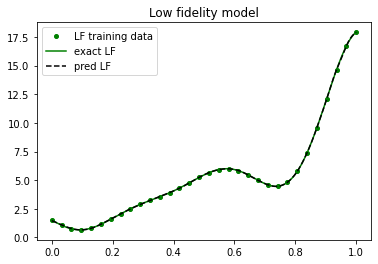

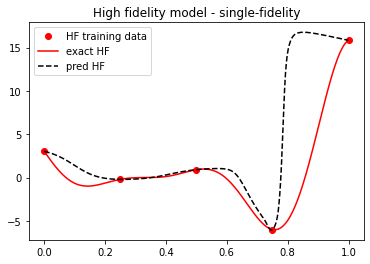

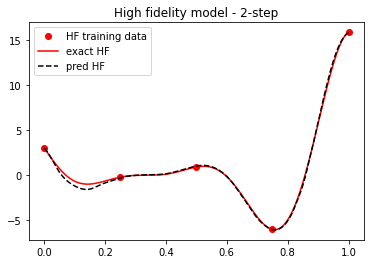

In [7]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC

In [8]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)
# Set parameters for the MCMC
n_samples = np.array([400,800,1200])  # Number of samples
proposal_sds = np.array([3.]) # Standard deviation for the proposal distribution
chain_length=4


In [9]:
# from cuqi.problem import BayesianProblem
# A=Model(forward=modelLF.prediction,range_geometry=Continuous1D(5),domain_geometry=Continuous1D(5))
# x=Uniform(np.zeros(5),np.ones(5))
# y=Gaussian(mean=A(x),cov=proposal_sds[0])
# y_obs=y(x=real_x).sample()
# posterior=JointDistribution(y,x)(y=y_obs)
# BP=BayesianProblem(y,x).set_data(y=y_obs)
# BP.UQ()

In [28]:

class Function:
    def __init__(self, func):
        """
        Initialize the class with a given function.

        Parameters:
        - func: The function for which we want to compute the Jacobian.
        """
        self.func = func

    def compute_jacobian(self, x):
        """
        Compute the Jacobian matrix for the given point x.

        Parameters:
        - x: The point at which to compute the Jacobian.

        Returns:
        - The Jacobian matrix.
        """
        x = np.atleast_1d(x).astype(float)
        n = len(x)
        m = len(self.func(x))

        jacobian = np.zeros((m, n))

        for i in range(n):
            x_copy1 = x.copy()
            x_copy2 = x.copy()

            # Perturb the i-th element
            h = 1e-8
            x_copy1[i] += h
            x_copy2[i] -= h

            # Compute partial derivative using finite difference
            jacobian[:, i] = (self.func(x_copy1) - self.func(x_copy2)) / (2 * h)

        return jacobian

    # def get_jacobian_at_point(self, x):
    #     """
    #     Compute the Jacobian matrix at a specific point.

    #     Parameters:
    #     - x: The point at which to compute the Jacobian.

    #     Returns:
    #     - The Jacobian matrix at the given point.
    #     """
    #     return self.compute_jacobian(x)


# Create an instance of the class
LF_func = Function(modelLF.prediction)
HF_func=Function(modelHF.prediction)
MF_func=Function(final_model.prediction)
# Compute the Jacobian at a specific point
Low_jac = LF_func.compute_jacobian
High_jac = LF_func.compute_jacobian
MF_jac = MF_func.compute_jacobian

# print("Function value at {}: {}".format(point, quadratic_function(point)))
# print("Jacobian at {}: \n{}".format(point, jacobian_at_point))


### Low Fidelity

********************  # Variance = 3.0  ********************
********************  # Steps = 400  ********************


Sample 400 / 400

Average acceptance rate: 0.145 MCMC scale: 0.07325694515248143 

********************  # Mean values = [0.27049815 0.1449065  0.50481828 0.5981756  0.88975664]  ********************
Sample 400 / 400

Average acceptance rate: 0.25 MCMC scale: 0.07885983541988602 

********************  # Mean values = [0.40764022 0.19963674 0.55241679 0.63247739 0.89013335]  ********************
Sample 400 / 400

Average acceptance rate: 0.185 MCMC scale: 0.09045552637444876 

********************  # Mean values = [0.46158834 0.1880933  0.54896519 0.61500478 0.89146576]  ********************
Sample 400 / 400

Average acceptance rate: 0.24 MCMC scale: 0.10487651014506905 

********************  # Mean values = [0.51525992 0.20813723 0.56581158 0.61467563 0.88956485]  ********************


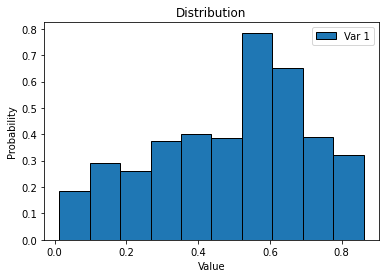

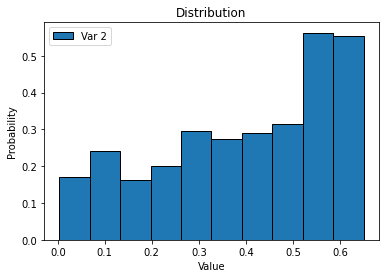

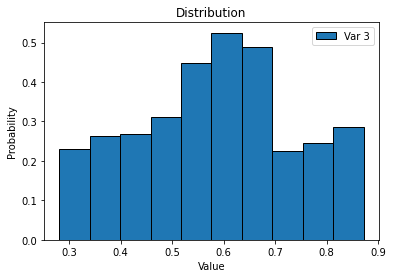

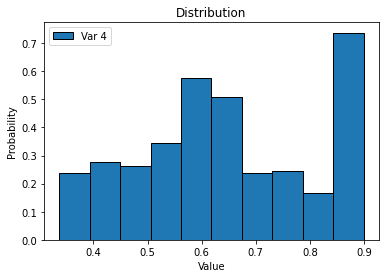

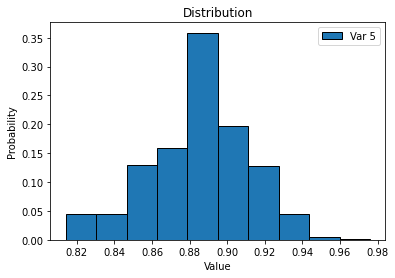

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 8.133676297668687  ********************


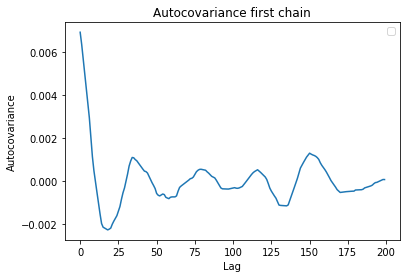

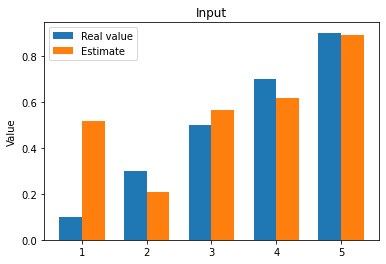

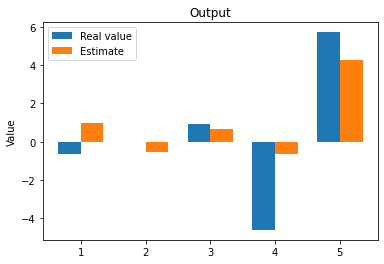

********************  # Variance = 3.0  ********************
********************  # Steps = 800  ********************
Sample 800 / 800

Average acceptance rate: 0.205 MCMC scale: 0.07211212158141408 

********************  # Mean values = [0.22638584 0.15647021 0.33907575 0.55502035 0.92908012]  ********************
Sample 800 / 800

Average acceptance rate: 0.155 MCMC scale: 0.07385232956602603 

********************  # Mean values = [0.19341614 0.13511359 0.49020087 0.51759252 0.9328203 ]  ********************
Sample 800 / 800

Average acceptance rate: 0.19 MCMC scale: 0.08097720143605948 

********************  # Mean values = [0.20823412 0.13074734 0.53885445 0.53000284 0.93331795]  ********************
Sample 800 / 800

Average acceptance rate: 0.15833333333333333 MCMC scale: 0.07942755361066761 

********************  # Mean values = [0.2114805  0.12426364 0.52794133 0.54951412 0.9319698 ]  ********************


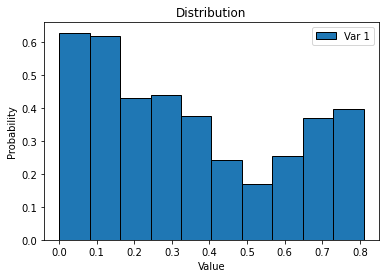

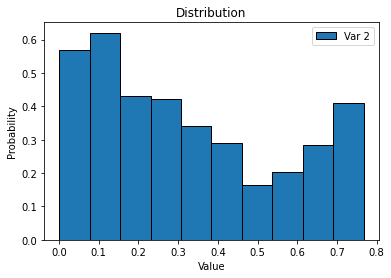

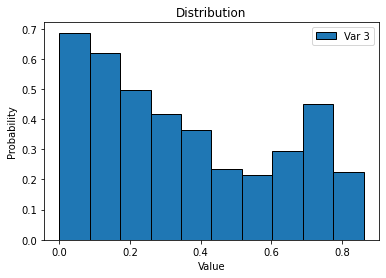

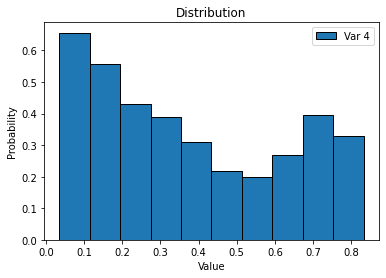

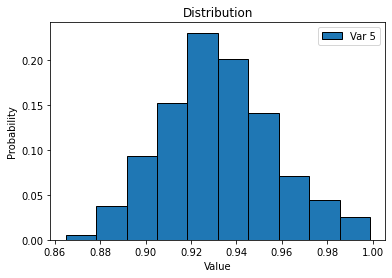

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 17.397568400160708  ********************


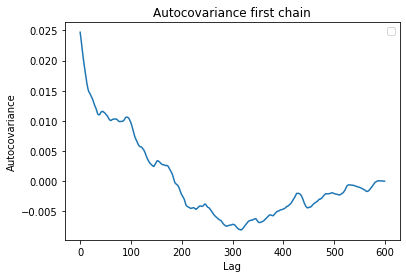

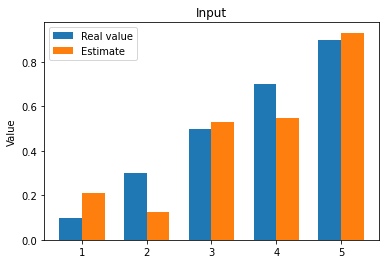

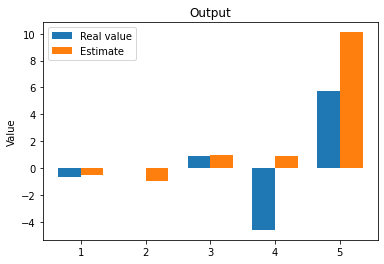

********************  # Variance = 3.0  ********************
********************  # Steps = 1200  ********************
Sample 1200 / 1200

Average acceptance rate: 0.174 MCMC scale: 0.08446631699197028 

********************  # Mean values = [0.24570178 0.22789777 0.615708   0.56388705 0.94818098]  ********************
Sample 1200 / 1200

Average acceptance rate: 0.189 MCMC scale: 0.08613375336938954 

********************  # Mean values = [0.3490739  0.20804588 0.59703815 0.51394361 0.94944274]  ********************
Sample 1200 / 1200

Average acceptance rate: 0.202 MCMC scale: 0.07833842673145316 

********************  # Mean values = [0.37220921 0.19293264 0.59831862 0.52409707 0.94890022]  ********************
Sample 1200 / 1200

Average acceptance rate: 0.204 MCMC scale: 0.08329602361025272 

********************  # Mean values = [0.381724   0.18687846 0.59267344 0.52051897 0.94857459]  ********************


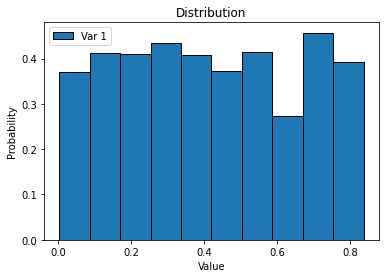

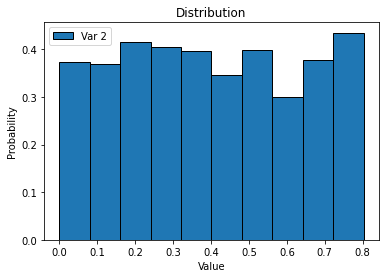

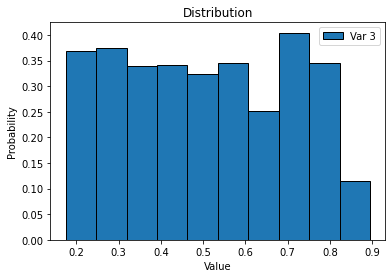

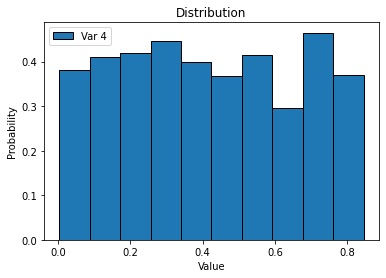

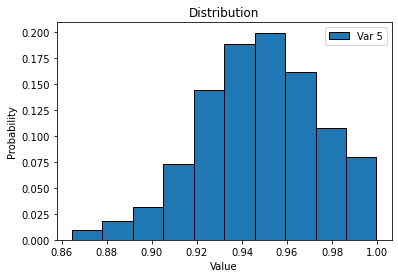

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 37.907375831892445  ********************


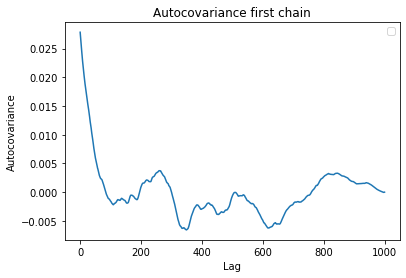

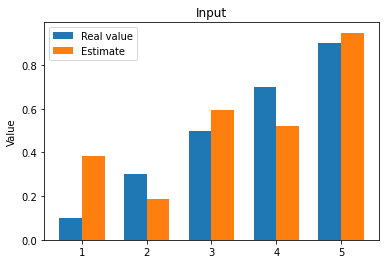

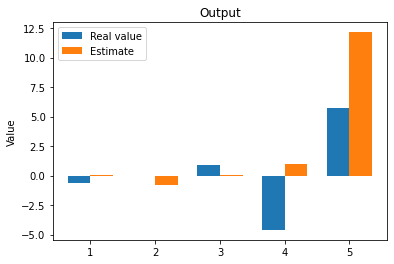

In [11]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )
        

        estimates=modelLF.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        
        

********************  # Variance = 3.0  ********************
********************  # Steps = 400  ********************


Sample 400 / 400

Average acceptance rate: 0.19 MCMC scale: 0.09138579329932459 

********************  # Mean values = [0.12384829 0.1693616  0.09042568 0.11097552 0.68346629]  ********************
Sample 400 / 400

Average acceptance rate: 0.275 MCMC scale: 0.07875035835644902 

********************  # Mean values = [0.16988127 0.15678599 0.0807958  0.10391897 0.58932987]  ********************
Sample 400 / 400

Average acceptance rate: 0.22 MCMC scale: 0.07446680557336104 

********************  # Mean values = [0.35426667 0.14949429 0.10355827 0.10289114 0.6199724 ]  ********************
Sample 400 / 400

Average acceptance rate: 0.185 MCMC scale: 0.10418569092234745 

********************  # Mean values = [0.31821304 0.15069018 0.11708052 0.09759202 0.63005914]  ********************


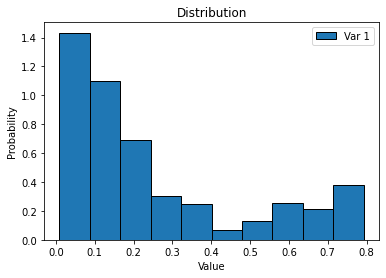

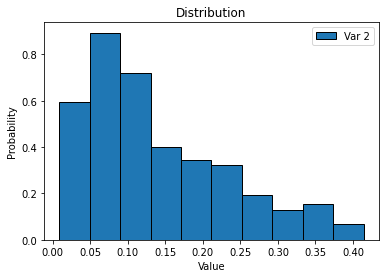

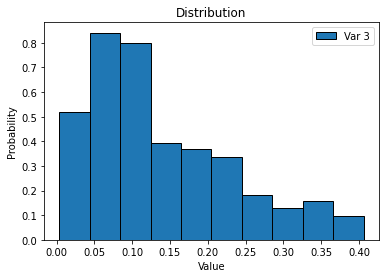

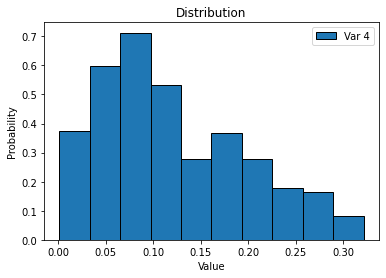

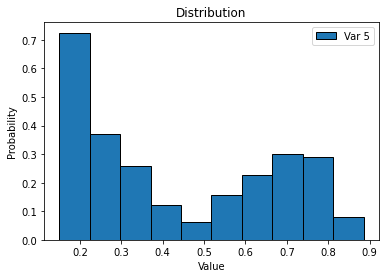

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 5.649327371366257  ********************


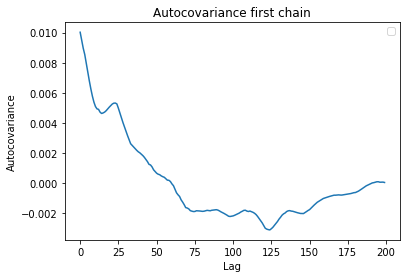

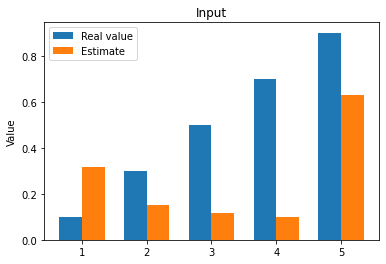

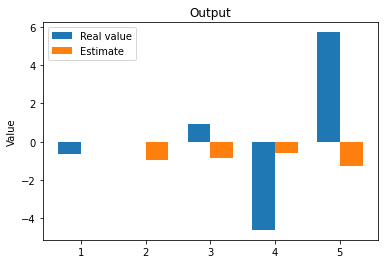

********************  # Variance = 3.0  ********************
********************  # Steps = 800  ********************
Sample 800 / 800

Average acceptance rate: 0.2783333333333333 MCMC scale: 0.09842047405010104 

********************  # Mean values = [0.15562911 0.19580267 0.40528701 0.10251663 0.50836841]  ********************
Sample 800 / 800

Average acceptance rate: 0.215 MCMC scale: 0.09118670578037288 

********************  # Mean values = [0.1320575  0.17567787 0.31951594 0.10232983 0.58986602]  ********************
Sample 800 / 800

Average acceptance rate: 0.215 MCMC scale: 0.10034095858766147 

********************  # Mean values = [0.13229362 0.17460308 0.29024289 0.10099156 0.56482388]  ********************
Sample 800 / 800

Average acceptance rate: 0.22333333333333333 MCMC scale: 0.08938451311853914 

********************  # Mean values = [0.13596417 0.16811843 0.2794641  0.10291264 0.58975254]  ********************


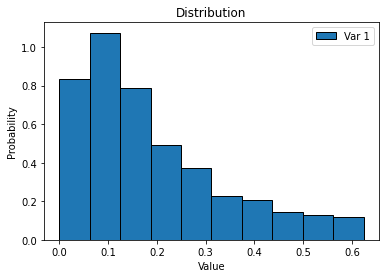

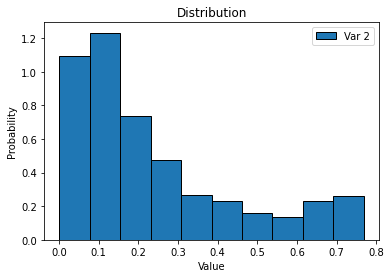

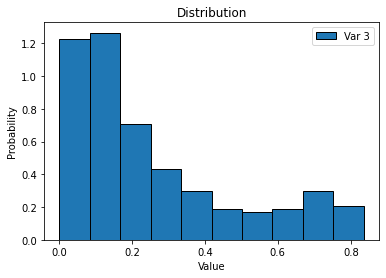

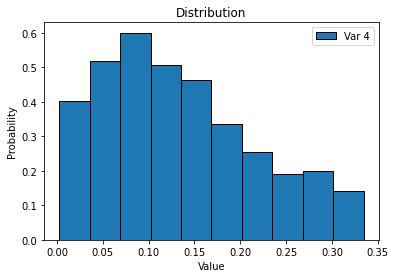

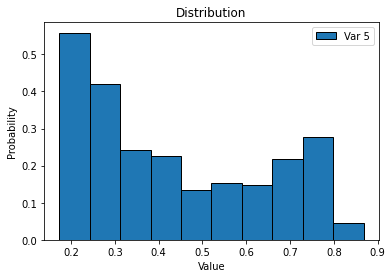

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 125.66004026996632  ********************


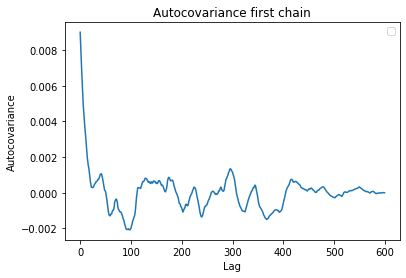

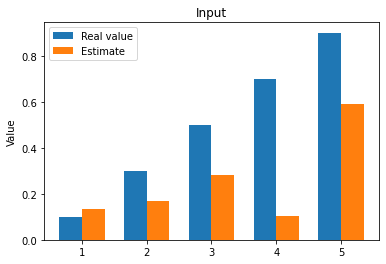

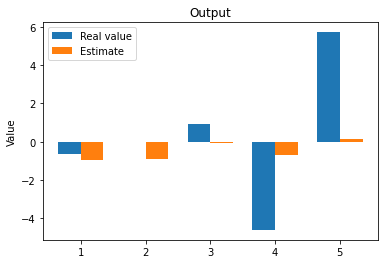

********************  # Variance = 3.0  ********************
********************  # Steps = 1200  ********************
Sample 1200 / 1200

Average acceptance rate: 0.252 MCMC scale: 0.08179834232651725 

********************  # Mean values = [0.1254882  0.21640567 0.27935605 0.22410515 0.67891722]  ********************
Sample 1200 / 1200

Average acceptance rate: 0.228 MCMC scale: 0.09613557605151071 

********************  # Mean values = [0.12736189 0.17928388 0.26892713 0.16246698 0.65897129]  ********************
Sample 1200 / 1200

Average acceptance rate: 0.236 MCMC scale: 0.1013864730146307 

********************  # Mean values = [0.13059003 0.16785341 0.27430381 0.14304131 0.61233922]  ********************
Sample 1200 / 1200

Average acceptance rate: 0.202 MCMC scale: 0.0945538426248196 

********************  # Mean values = [0.13596127 0.16079762 0.30332476 0.12964467 0.62500697]  ********************


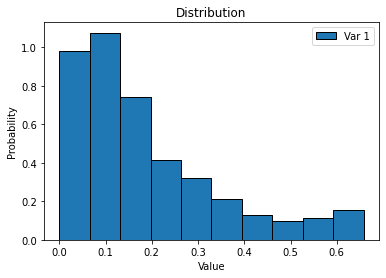

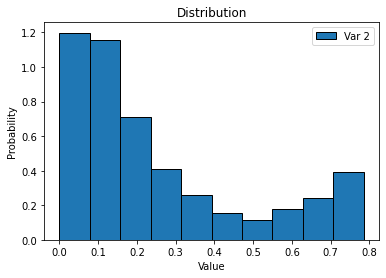

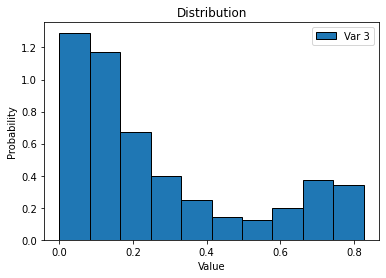

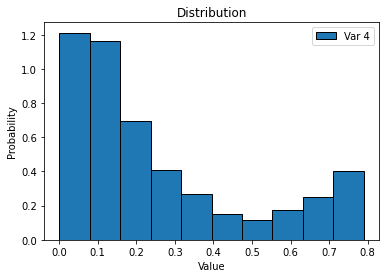

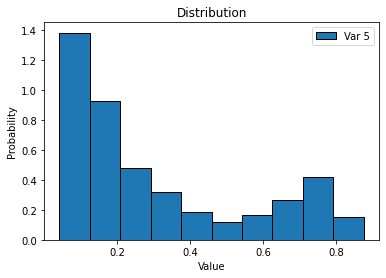

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 155.83511368960757  ********************


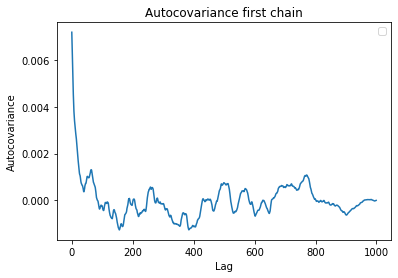

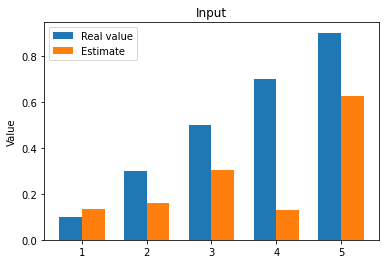

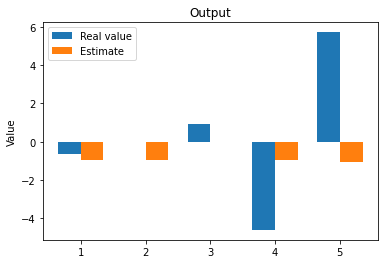

In [10]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )
        

        estimates=modelLF.inverse(x_real=real_x,y_obs=observed_output,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        
        

In [9]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )
        

        estimates=modelLF.inverse(x_real=real_x,y_obs=observed_output,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd, algo="NUTS")
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        
        

********************  # Variance = 3.0  ********************
********************  # Steps = 400  ********************


Sample 400 / 400
********************  # Mean values = [0.16911084 0.00394827 0.72175532 0.54254437 0.44183317]  ********************
Sample 400 / 400
********************  # Mean values = [0.1436502  0.2675496  0.52692617 0.31699276 0.3806286 ]  ********************
Sample 8 / 400

KeyboardInterrupt: 

In [ ]:
# from scipy.interpolate import interp1d
# # rendila un decorator
# def estimate_gradient(x, y, new_value_x):
#     """
#     Calcola una stima del gradiente nei punti specificati dati gli array x e y.

#     Parametri:
#     - x: array NumPy contenente le coordinate x dei dati.
#     - y: array NumPy contenente le coordinate y dei dati.
#     - punti: array NumPy contenente i punti in cui si vuole stimare il gradiente.

#     Ritorna:
#     - gradiente: array NumPy contenente le stime del gradiente nei punti specificati.
#     """

#     # Verifica che le dimensioni di x e y siano uguali
#     if x.shape != y.shape:
#         raise ValueError("Le dimensioni di x e y devono essere uguali.")

#     # Calcola la derivata rispetto a x
#     dx = np.gradient(x)

#     # Calcola la derivata rispetto a y
#     dy = np.gradient(y)

#     # Calcola il gradiente come rapporto tra le derivate rispetto a x e y
#     gradiente = dy / dx

#     # Utilizza la funzione np.interp per stimare il gradiente nei punti specificati
#     gradiente_stimato = np.interp(new_value_x, x, gradiente)

#     return gradiente_stimato


# def gradient_LF(value):
    
#     return estimate_gradient(x_test,yLF,value)

In [ ]:
# # Introduction of the model and of the first step


# # ATTENZIONE!  in caso LF non si dovrebbe mettere comunque forward=modelHF?
# A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# num_bins = 10

# for sd in proposal_sds:
#     print(                f"********************  # Variance = {sd}  ********************"
#                 )
    
#     # prior 
#     y_LF=Gaussian(mean=A_LF(x_LF),cov=sd)
#     y_obs=y_LF(x_LF=real_x).sample()
#     posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
#     x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

#     for N in n_samples:
#         print(                f"********************  # Steps = {N}  ********************"
#                 )
#         # Sampler, here Metropolis hastings
#         MHsampler_LF=MH(posterior_LF,x0=x_init)
        
#         estimates=np.empty((x_init.shape[0],0))
#         chains=np.empty((0,x_init.shape[0],N))
#         post=np.empty((x_init.shape[0],0))
        
#         for i in range(chain_length):
#                 samplesMH_LF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
#                 estimates=np.column_stack((estimates,samplesMH_LF.mean()[:, np.newaxis]))
#                 # chains=np.concatenate(chains, samplesMH_LF.samples)
#                 chains = np.concatenate((chains, np.expand_dims(samplesMH_LF.samples, axis=0)), axis=0)

#                 post=np.concatenate((post,samplesMH_LF.samples),axis=1)
        
#         print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
#                 )
          
#         for num in range(post.shape[0]):        
#                 bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
#                 hist, _ = np.histogram(post, bins=bin_edges)
#                 hist=hist/post.shape[1]
#                 bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#                 plt.figure()
#                 plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

#                 plt.xlabel('Value')
#                 plt.ylabel('Probability')
#                 plt.title('Distribution')
#                 plt.legend()
#                 plt.show()
                
#                 # plt.figure()
#                 # plt.plot(np.mean(chains,axis=(0,2)))
#                 # plt.xlabel('Step')
#                 # plt.title(f'Averaged chain var {num+1}')
#                 # plt.show()

                
                
                
# # samplesMH_LF.plot_trace()
# # print("mean value")
# # print(samplesMH_LF.mean())
# # print("ESS")
# # print(samplesMH_LF.compute_ess())
# # samplesMH_LF.plot_autocorrelation()

c:\Users\Giacomo\Desktop\PACS_codice\pacs_new\PACS_project2\1DBench_MCMC\generalization.py:130: UserWarning: No observation nor data given
  warnings.warn(warning_message, UserWarning)


UnboundLocalError: local variable 'dim' referenced before assignment

#### prova hmc

In [ ]:
#from cuqi.distribution import Beta

In [ ]:
# real_x = np.array([0.1,0.3,0.5,0.7,0.9])
# observed_output = highfid(real_x)

# # Set parameters for the MCMC
# n_samples = np.array([10,800,1200])  # Number of samples
# initial_x = 0.5 # Initial value for x
# proposal_sds = np.array([0.1,0.25,0.5,0.75,1.]) # Standard deviation for the proposal distribution
# chain_length=2

********************  # Variance = 0.1  ********************
********************  # Steps = 10  ********************


Sample 15 / 15
Sample 15 / 15
********************  # Mean values = [0.30188455 0.44248868 0.46951089 0.51347088 0.54969043]  ********************


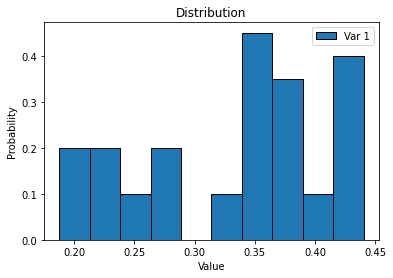

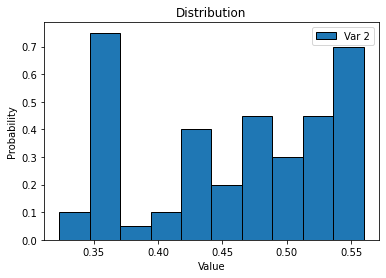

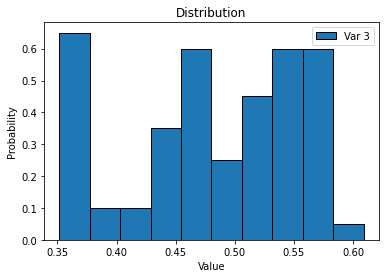

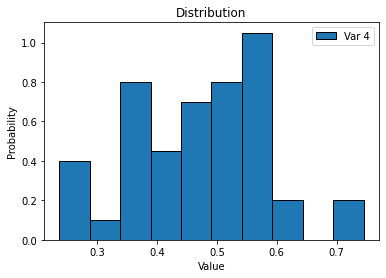

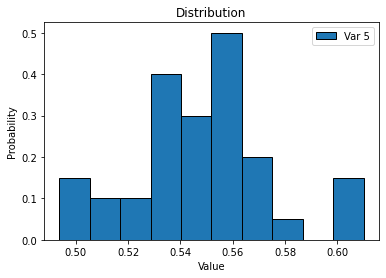

********************  # Steps = 800  ********************
Sample 1200 / 1200
Sample 1200 / 1200
********************  # Mean values = [0.48887202 0.48154788 0.48417455 0.48368852 0.49635091]  ********************


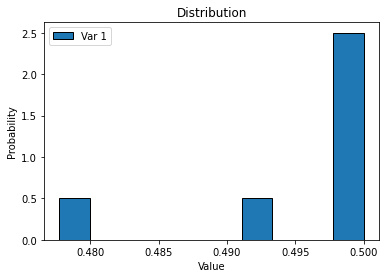

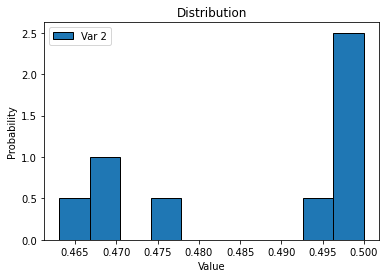

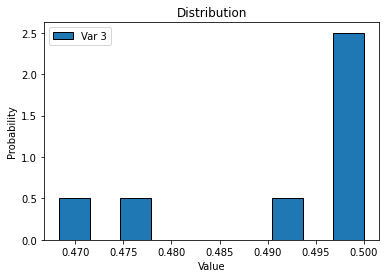

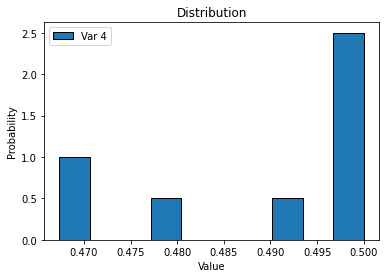

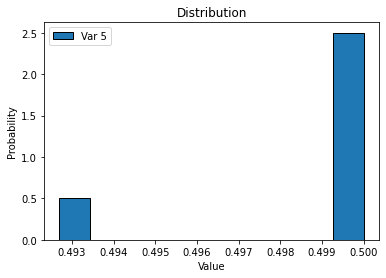

********************  # Steps = 1200  ********************
Sample 1800 / 1800


KeyboardInterrupt: 

In [ ]:
# A_LF=Model(forward=modelLF.prediction, jacobian=gradient_LF,range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_LF=Beta(alpha=2*np.ones(5),beta=2*np.ones(5))  # <------
# num_bins = 10

# for sd in proposal_sds:
#     print(                f"********************  # Variance = {sd}  ********************"
#                 )
#     y_LF=Gaussian(mean=A_LF(x_LF),cov=sd)
#     y_obs=y_LF(x_LF=real_x).sample()
#     posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
#     x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

#     for N in n_samples:
#         print(                f"********************  # Steps = {N}  ********************"
#                 )
#         MHsampler_LF=NUTS(posterior_LF,x0=x_init)
#         estimates=np.empty((x_init.shape[0],0))
#         chains=np.empty((0,x_init.shape[0],N))
#         post=np.empty((x_init.shape[0],0))
#         for i in range(chain_length):
#                 samplesMH_LF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
#                 estimates=np.column_stack((estimates,samplesMH_LF.mean()[:, np.newaxis]))
#                 # chains=np.concatenate(chains, samplesMH_LF.samples)
#                 chains = np.concatenate((chains, np.expand_dims(samplesMH_LF.samples, axis=0)), axis=0)

#                 post=np.concatenate((post,samplesMH_LF.samples),axis=1)
        
#         print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
#                 )
          
#         for num in range(post.shape[0]):        
#                 bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
#                 hist, _ = np.histogram(post, bins=bin_edges)
#                 hist=hist/post.shape[1]
#                 bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#                 plt.figure()
#                 plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

#                 plt.xlabel('Value')
#                 plt.ylabel('Probability')
#                 plt.title('Distribution')
#                 plt.legend()
#                 plt.show()
                
#                 # plt.figure()
#                 # plt.plot(np.mean(chains,axis=(0,2)))
#                 # plt.xlabel('Step')
#                 # plt.title(f'Averaged chain var {num+1}')
#                 # plt.show()

                
                
                
# # samplesMH_LF.plot_trace()
# # print("mean value")
# # print(samplesMH_LF.mean())
# # print("ESS")
# # print(samplesMH_LF.compute_ess())
# # samplesMH_LF.plot_autocorrelation()

In [ ]:
# #proposal_sd=np.exp(-(d-y_obs)**2/(np.sqrt(2*0.3)))

# A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))

# d=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))

# y_LF=Gaussian(A_LF(x_LF),lambda d: np.exp(-(d-modelHF.prediction(real_x))**2/(np.sqrt(2*0.3))))      # ATTENZIONE! NON SO SE SENSATO METTERE QUA PREDICTION, A QUEL PUNTO RUOLO DI y_obs sotto? E poi, si deve valutare NN(x_step) o  NN(real_x)?
# y_obs=y_LF(x_LF=real_x, d=0.1*np.ones(5)).sample()    # d=modelLF.prediction(real_x)
# posterior_LF=JointDistribution(y_LF,x_LF,d)(y_LF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])
# MHsampler_LF = MH(posterior_LF, x0=x_init)   #x0=np.vstack(x_init, modelLF.prediction(x_init)

# estimates=np.empty((x_init.shape[0],0))
# chains=np.empty((0,x_init.shape[0],n_samples))

# chain_length=8
# n_samples=600
# for i in range(chain_length):
#     samplesMH_LF=MHsampler_LF.sample_adapt(n_samples,int(n_samples/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
#     estimates=np.column_stack((estimates,samplesMH_LF.mean()[:, np.newaxis]))
#     # chains=np.concatenate(chains, samplesMH_LF.samples)
#     chains = np.concatenate((chains, np.expand_dims(samplesMH_LF.samples, axis=0)), axis=0)

    
# print(samplesMH_LF.mean().shape)    
# print(estimates)
# print(estimates.shape)
# print(chains.shape)    

# print("MEAN VALUES")
# print(estimates.mean(axis=1))

# # samplesMH_LF.plot_trace()
# # print("mean value")
# # print(samplesMH_LF.mean())
# # print("ESS")
# # print(samplesMH_LF.compute_ess())
# # samplesMH_LF.plot_autocorrelation()

In [ ]:
#plt.plot(samplesMH_LF.samples[0,:])

In [ ]:
# samplesMH_LF.plot_violin()

In [ ]:
# A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# y_HF=Gaussian(mean=A_HF(x_HF),cov=proposal_sd)
# y_obs=y_HF(x_HF=real_x).sample()
# posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

# MHsampler_HF=MH(posterior_HF,x0=x_init)
# samplesMH_HF=MHsampler_HF.sample_adapt(n_samples,n_samples)

# samplesMH_HF.plot_trace()
# print(samplesMH_HF.mean())
# print(samplesMH_HF.compute_ess())
# samplesMH_HF.plot_autocorrelation()

### High Fidelity

********************  # Variance = 0.1  ********************
********************  # Steps = 400  ********************
Sample 400 / 400

Average acceptance rate: 0.095 MCMC scale: 0.03992423212398987 

(0, 5, 200)
(5, 200)
(1, 5, 200)
********************  # Mean values = [0.07488899 0.28907048 0.5874876  0.26740132 0.88507827]  ********************
********************  # ESS values = [21.09035545  1.30501682  1.70608734  8.6920258  11.94148686]  ********************
********************  # Rhat values = [21.09035545  1.30501682  1.70608734  8.6920258  11.94148686]  ********************
Sample 400 / 400

Average acceptance rate: 0.11 MCMC scale: 0.022718155441926006 

(1, 5, 200)
(5, 200)
(1, 5, 200)
********************  # Mean values = [0.32812026 0.4620356  0.36488875 0.25939596 0.72600089]  ********************
********************  # ESS values = [14.52580471  6.1606765   4.41940754  8.990579   10.782767  ]  ********************
********************  # Rhat values = [14.52580471 

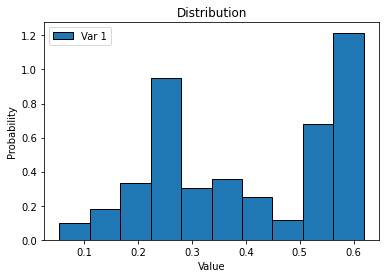

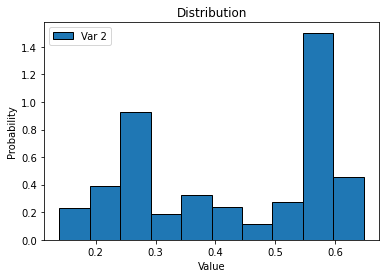

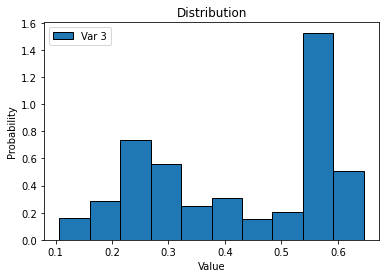

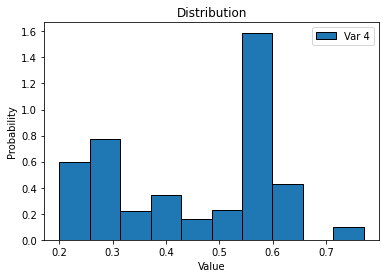

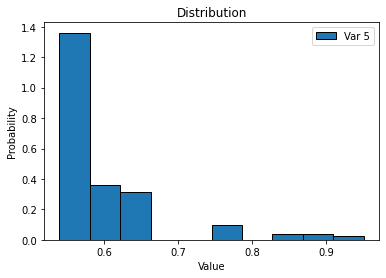

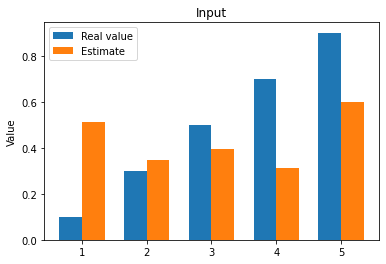

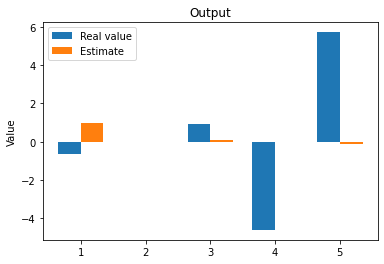

********************  # Variance = 0.1  ********************
********************  # Steps = 800  ********************
Sample 800 / 800

Average acceptance rate: 0.095 MCMC scale: 0.052858055936922915 

(0, 5, 600)
(5, 600)
(1, 5, 600)
********************  # Mean values = [0.55841546 0.44078749 0.33516351 0.26239888 0.90283216]  ********************
********************  # ESS values = [10.50144353  1.8432794  14.69125757 25.23381404  4.39974883]  ********************
********************  # Rhat values = [10.50144353  1.8432794  14.69125757 25.23381404  4.39974883]  ********************
Sample 800 / 800

Average acceptance rate: 0.17166666666666666 MCMC scale: 0.029493005722739635 

(1, 5, 600)
(5, 600)
(1, 5, 600)
********************  # Mean values = [0.54932686 0.38520096 0.38459637 0.26423764 0.73528935]  ********************
********************  # ESS values = [10.03748185  7.45274991 14.47654292 25.0326588  19.86763119]  ********************
********************  # Rhat values

KeyboardInterrupt: 

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=modelHF.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

In [ ]:
# A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# num_bins = 10

# for sd in proposal_sds:
#     print(                f"********************  # Variance = {sd}  ********************"
#                 )
#     y_HF=Gaussian(mean=A_HF(x_HF),cov=sd)
#     y_obs=y_HF(x_HF=real_x).sample()
#     posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
#     x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

#     for N in n_samples:
#         print(                f"********************  # Steps = {N}  ********************"
#                 )
#         MHsampler_HF=MH(posterior_HF,x0=x_init)
#         estimates=np.empty((x_init.shape[0],0))
#         chains=np.empty((0,x_init.shape[0],N))
#         post=np.empty((x_init.shape[0],0))
#         for i in range(chain_length):
#                 samplesMH_HF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
#                 estimates=np.column_stack((estimates,samplesMH_HF.mean()[:, np.newaxis]))
#                 # chains=np.concatenate(chains, samplesMH_LF.samples)
#                 chains = np.concatenate((chains, np.expand_dims(samplesMH_HF.samples, axis=0)), axis=0)

#                 post=np.concatenate((post,samplesMH_HF.samples),axis=1)
        
#         print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
#                 )
          
#         for num in range(post.shape[0]):        
#                 bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
#                 hist, _ = np.histogram(post, bins=bin_edges)
#                 hist=hist/post.shape[1]
#                 bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#                 plt.figure()
#                 plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

#                 plt.xlabel('Value')
#                 plt.ylabel('Probability')
#                 plt.title('Distribution')
#                 plt.legend()
#                 plt.show()
                
#                 plt.figure()
#                 plt.plot(np.mean(chains,axis=(0,2)))
#                 plt.xlabel('Step')
#                 plt.title(f'Averaged chain var {num+1}')
#                 plt.show()

                
   

### MultiFidelity

********************  # Variance = 3.0  ********************
********************  # Steps = 400  ********************


Sample 400 / 400

Average acceptance rate: 0.065 MCMC scale: 0.0318215318632316 

********************  # Mean values = [0.27280777 0.65259577 0.86439746 0.13942566 0.0119435 ]  ********************
Sample 400 / 400

Average acceptance rate: 0.11 MCMC scale: 0.037210177487355243 

********************  # Mean values = [0.55574937 0.75604213 0.52341395 0.15840488 0.2700485 ]  ********************
Sample 400 / 400

Average acceptance rate: 0.115 MCMC scale: 0.04743909747141468 

********************  # Mean values = [0.45499536 0.57109232 0.4138697  0.1668673  0.18504904]  ********************
Sample 400 / 400

Average acceptance rate: 0.19 MCMC scale: 0.0542131385015029 

********************  # Mean values = [0.40065689 0.55190328 0.40894112 0.16935379 0.36242843]  ********************


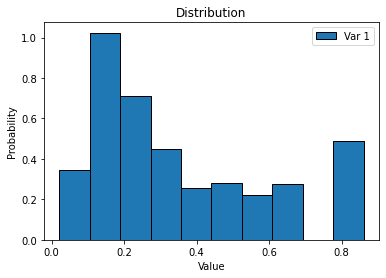

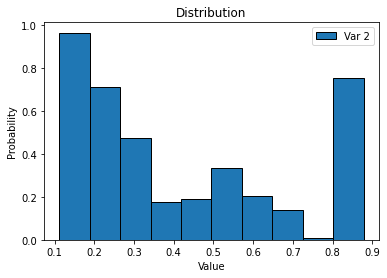

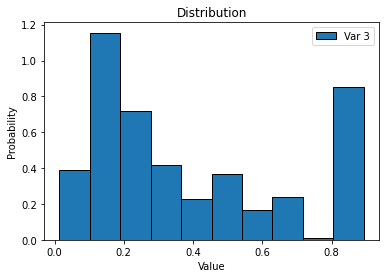

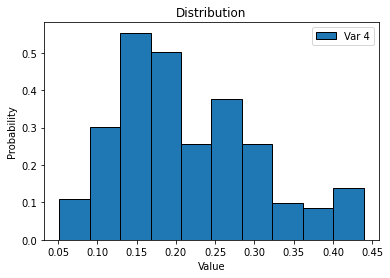

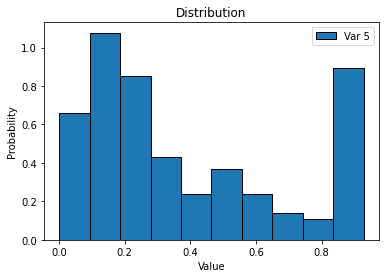

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 5.386057843346127  ********************


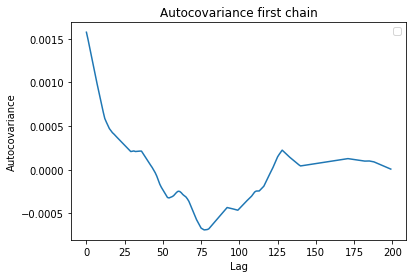

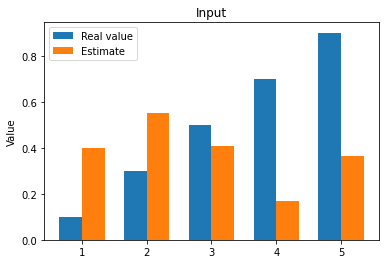

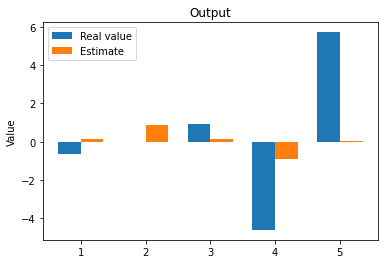

********************  # Variance = 3.0  ********************
********************  # Steps = 800  ********************
Sample 800 / 800

Average acceptance rate: 0.14 MCMC scale: 0.08534682125508071 

********************  # Mean values = [0.19823099 0.43025742 0.35238536 0.16453787 0.26788688]  ********************
Sample 800 / 800

Average acceptance rate: 0.13166666666666665 MCMC scale: 0.05235908050838853 

********************  # Mean values = [0.32279321 0.28383556 0.28731157 0.4523701  0.5867641 ]  ********************
Sample 800 / 800

Average acceptance rate: 0.29833333333333334 MCMC scale: 0.08838222612413689 

********************  # Mean values = [0.34628047 0.29229044 0.30649435 0.36345351 0.54637186]  ********************
Sample 800 / 800

Average acceptance rate: 0.235 MCMC scale: 0.09874442349772591 

********************  # Mean values = [0.31294397 0.30773261 0.30755545 0.4600273  0.52768974]  ********************


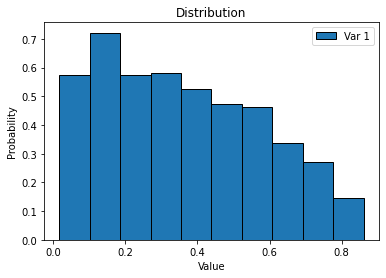

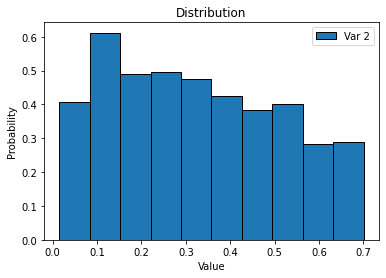

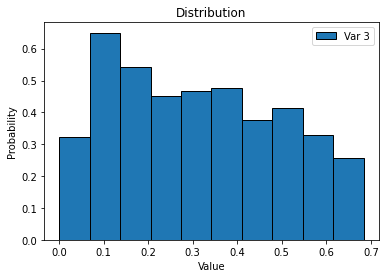

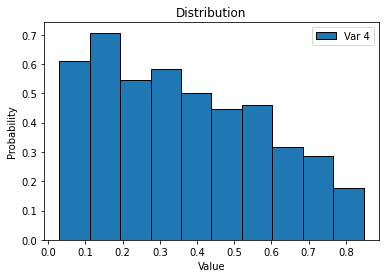

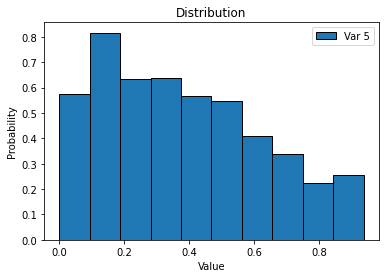

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 9.536055056328875  ********************


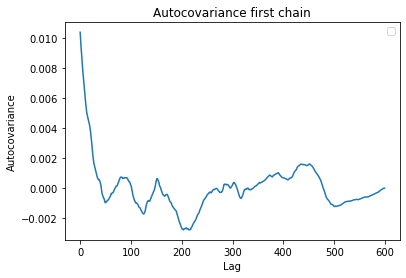

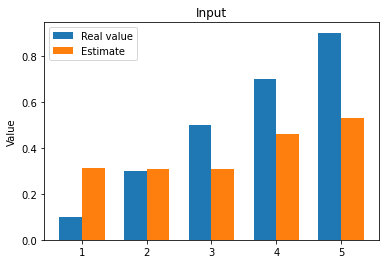

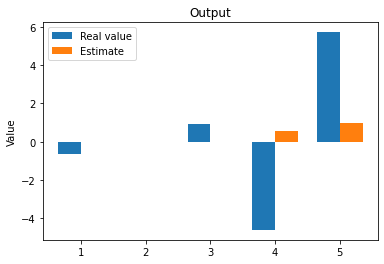

********************  # Variance = 3.0  ********************
********************  # Steps = 1200  ********************
Sample 1200 / 1200

Average acceptance rate: 0.217 MCMC scale: 0.07802338251604803 

********************  # Mean values = [0.68621491 0.57283886 0.42641827 0.32809308 0.36313883]  ********************
Sample 1200 / 1200

Average acceptance rate: 0.211 MCMC scale: 0.07608732080600475 

********************  # Mean values = [0.51927532 0.35729086 0.35391198 0.52623546 0.31073823]  ********************
Sample 1200 / 1200

Average acceptance rate: 0.099 MCMC scale: 0.04494142331203264 

********************  # Mean values = [0.402434   0.485562   0.31711156 0.59580791 0.21275539]  ********************
Sample 1200 / 1200

Average acceptance rate: 0.17 MCMC scale: 0.0665883053383438 

********************  # Mean values = [0.4749528  0.49002878 0.35955396 0.54910034 0.22332289]  ********************


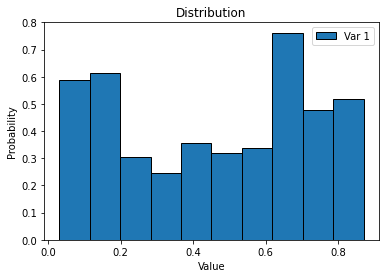

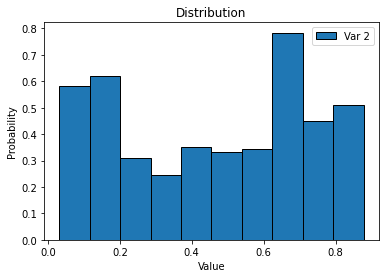

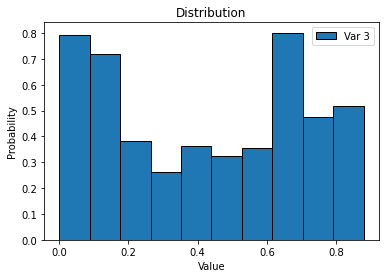

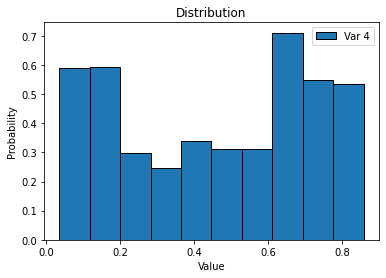

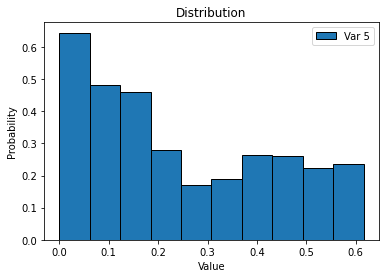

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 6.894467944944544  ********************


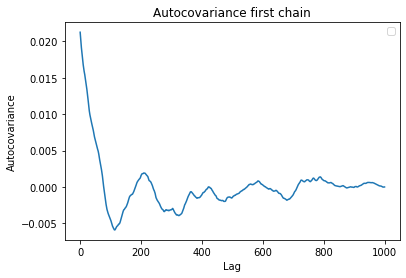

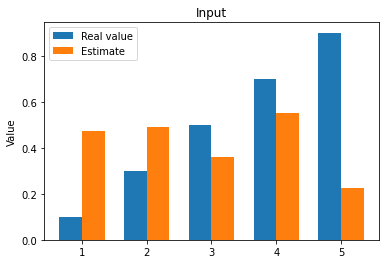

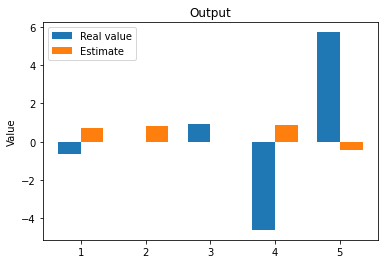

In [12]:
#proposal_sds=proposal_sds[2:3]

for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=final_model.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

********************  # Variance = 3.0  ********************
********************  # Steps = 400  ********************
Sample 400 / 400

Average acceptance rate: 0.09 MCMC scale: 0.055740900084889244 

********************  # Mean values = [0.20731817 0.62045078 0.19718056 0.78135028 0.9094536 ]  ********************
Sample 400 / 400

Average acceptance rate: 0.21 MCMC scale: 0.046615081507218124 

********************  # Mean values = [0.19686718 0.52302679 0.26646074 0.47522341 0.90492279]  ********************
Sample 400 / 400

Average acceptance rate: 0.135 MCMC scale: 0.04092092225732683 

********************  # Mean values = [0.20588217 0.63633635 0.19167523 0.55692537 0.90498137]  ********************
Sample 400 / 400

Average acceptance rate: 0.07 MCMC scale: 0.07341187064464307 

********************  # Mean values = [0.31419195 0.51463574 0.35987136 0.58860717 0.80069048]  ********************


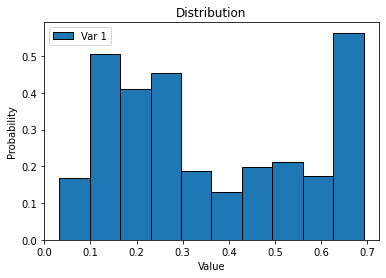

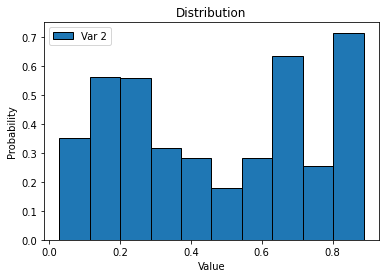

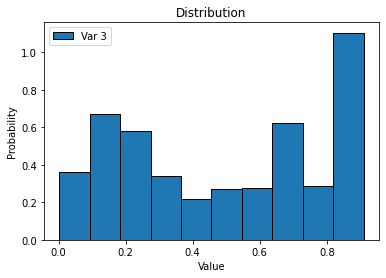

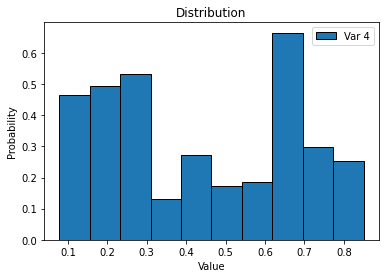

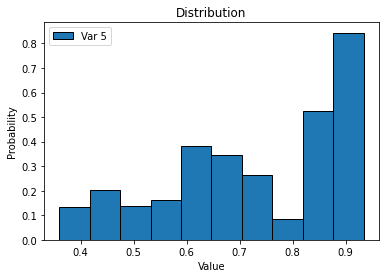

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 6.023904147079851  ********************


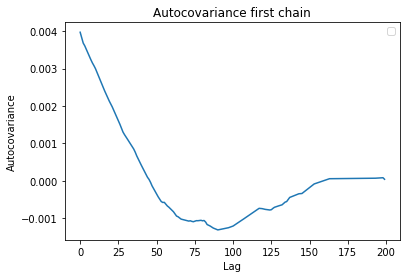

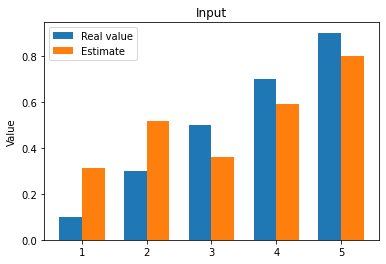

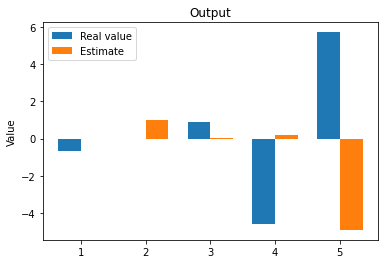

********************  # Variance = 3.0  ********************
********************  # Steps = 800  ********************
Sample 800 / 800

Average acceptance rate: 0.11166666666666666 MCMC scale: 0.03849564460585946 

********************  # Mean values = [0.85911432 0.45603468 0.49220528 0.17797245 0.89190263]  ********************
Sample 800 / 800

Average acceptance rate: 0.25333333333333335 MCMC scale: 0.07816567923322147 

********************  # Mean values = [0.546704   0.41029401 0.57321794 0.18306968 0.68550717]  ********************
Sample 800 / 800

Average acceptance rate: 0.17833333333333334 MCMC scale: 0.07918256371651122 

********************  # Mean values = [0.50127875 0.34641145 0.53624508 0.20581496 0.50060994]  ********************
Sample 800 / 800

Average acceptance rate: 0.17833333333333334 MCMC scale: 0.08169603368852148 

********************  # Mean values = [0.45602219 0.3833638  0.45739992 0.34661137 0.42704132]  ********************


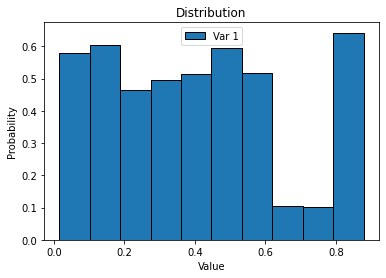

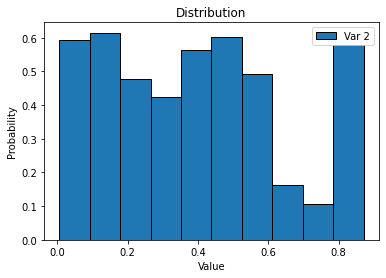

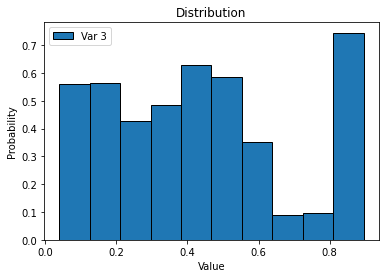

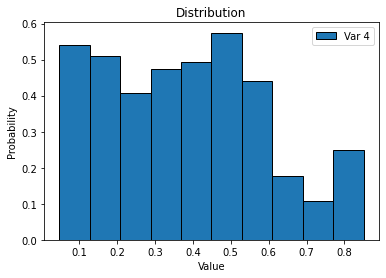

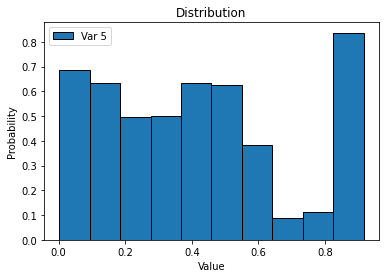

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 5.673391511000711  ********************


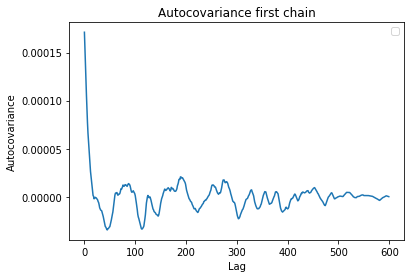

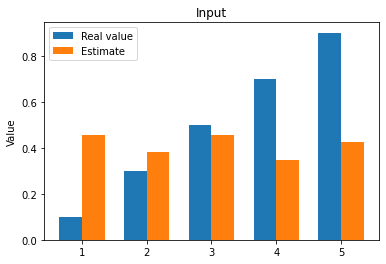

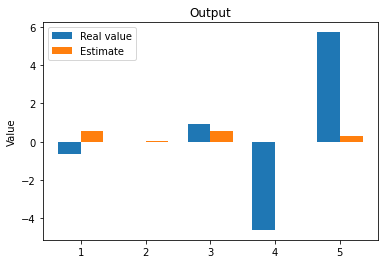

********************  # Variance = 3.0  ********************
********************  # Steps = 1200  ********************
Sample 1200 / 1200

Average acceptance rate: 0.153 MCMC scale: 0.053766120185371344 

********************  # Mean values = [0.35734296 0.38283323 0.33559482 0.74211818 0.89780708]  ********************
Sample 804 / 1200

KeyboardInterrupt: 

In [13]:
#proposal_sds=proposal_sds[2:3]

for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=final_model.inverse(x_real=real_x,y_obs=observed_output ,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

In [ ]:
# A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# num_bins = 10

# for sd in proposal_sds:
#     print(                f"********************  # Variance = {sd}  ********************"
#                 )
#     y_MF=Gaussian(mean=A_MF(x_MF),cov=sd)
#     y_obs=y_MF(x_MF=real_x).sample()
#     posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
#     x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

#     for N in n_samples:
#         print(                f"********************  # Steps = {N}  ********************"
#                 )
#         MHsampler_MF=MH(posterior_MF,x0=x_init)
#         estimates=np.empty((x_init.shape[0],0))
#         chains=np.empty((0,x_init.shape[0],N))
#         post=np.empty((x_init.shape[0],0))
#         for i in range(chain_length):
#                 samplesMH_MF=MHsampler_MF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
#                 estimates=np.column_stack((estimates,samplesMH_MF.mean()[:, np.newaxis]))
#                 # chains=np.concatenate(chains, samplesMH_LF.samples)
#                 chains = np.concatenate((chains, np.expand_dims(samplesMH_MF.samples, axis=0)), axis=0)

#                 post=np.concatenate((post,samplesMH_MF.samples),axis=1)
        
#         print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
#                 )
          
#         for num in range(post.shape[0]):        
#                 bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
#                 hist, _ = np.histogram(post, bins=bin_edges)
#                 hist=hist/post.shape[1]
#                 bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#                 plt.figure()
#                 plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

#                 plt.xlabel('Value')
#                 plt.ylabel('Probability')
#                 plt.title('Distribution')
#                 plt.legend()
#                 plt.show()
                
#                 plt.figure()
#                 plt.plot(np.mean(chains,axis=(0,2)))
#                 plt.xlabel('Step')
#                 plt.title(f'Averaged chain var {num+1}')
#                 plt.show()

                
   

Sample 600 / 600

Average acceptance rate: 0.13666666666666666 MCMC scale: 0.04012786795875335 



array([0.23507817, 0.53022968, 0.51405922, 0.21669816, 0.52535724])

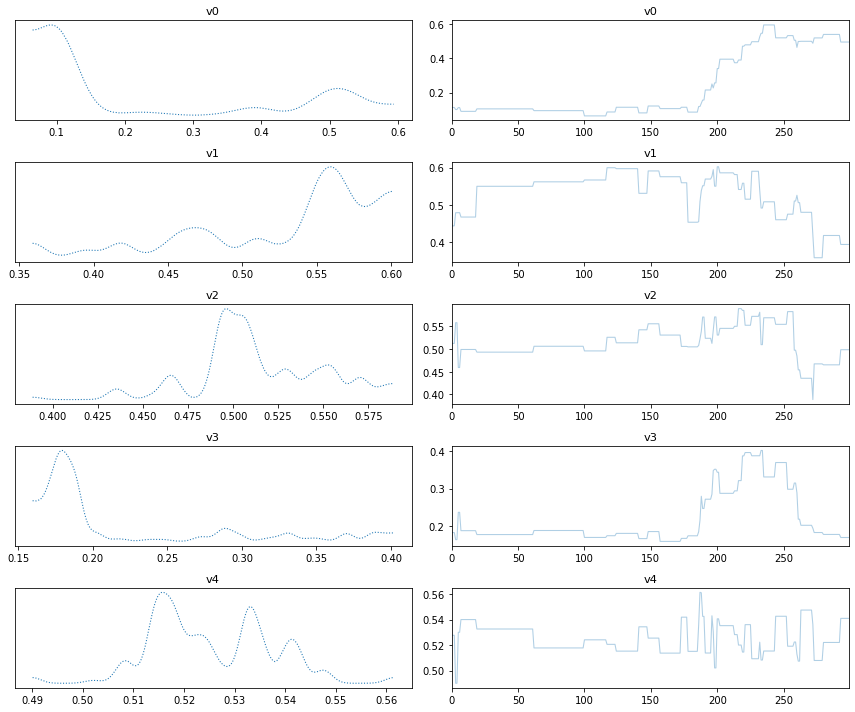

In [ ]:
# CODE SIMPLE

# A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# y_MF=Gaussian(mean=A_MF(x_MF),cov=proposal_sd)
# y_obs=y_MF(x_MF=real_x).sample()
# posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

# MHsampler_MF=MH(posterior_MF,x0=x_init)
# samplesMH_MF=MHsampler_MF.sample_adapt(n_samples,n_samples)

# samplesMH_MF.plot_trace()
# samplesMH_MF.mean()
# samplesMH_MF.compute_ess()
# samplesMH_MF.plot_autocorrelation()

# Discontinuous Benchmark

In [ ]:
lowfid = lambda x: (0.5*(6.*x-2.)**2*np.sin(12.*x-4)+10.*(x-0.5)-5.)*(x<0.5) + (3+0.5*(6.*x-2)**2*np.sin(12.*x-4)+10*(x-0.5)-5.)*(x>0.5)
highfid = lambda x: (2*lowfid(x)- 20*x+20)*(x<0.5) + (4+2*lowfid(x)- 20*x+20)*(x>0.5)
Nhf = 6
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 5000
NepoHF = 1200

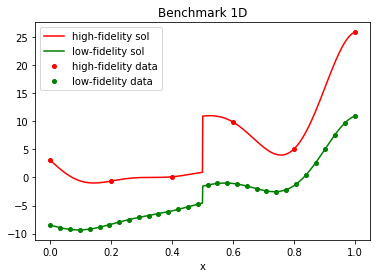

In [ ]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)

## High fidelity model

In [ ]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

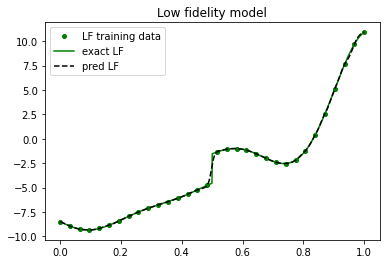

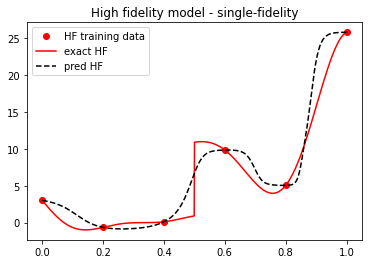

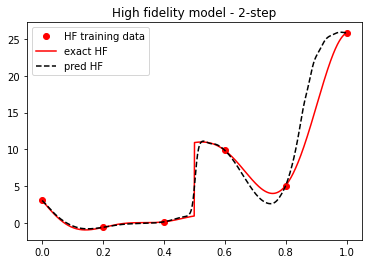

In [ ]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC

In [ ]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = np.array([400,800,1200])  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sds = np.array([0.1,0.25,0.5,0.75,1.]) # Standard deviation for the proposal distribution
chain_length=10

### Low Fidelity

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=modelLF.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

### High Fidelity

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=modelHF.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

### MultiFidelity

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=final_model.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

# Nonlinear correlation

OBS: "periodic" case seems not to work

In [ ]:
lowfid = lambda x: np.sin(8*np.pi*x)
highfid = lambda x: (x-np.sqrt(2))*lowfid(x)**2
Nhf = 15
Nlf = 64
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 3000
NepoHF = 3000

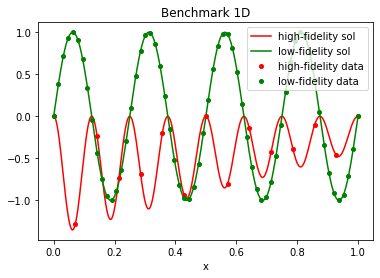

In [ ]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)

## High fidelity model

In [ ]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

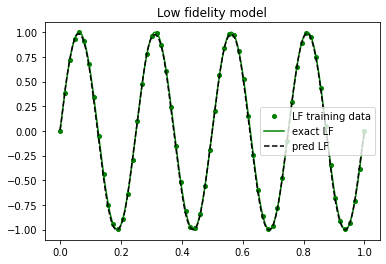

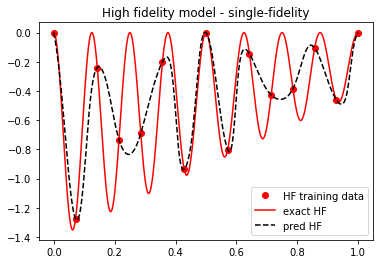

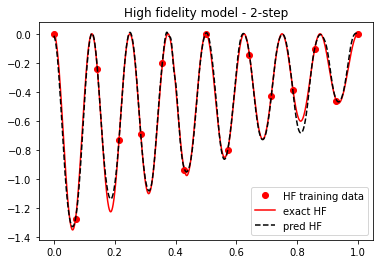

In [ ]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC

In [ ]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = 300  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sd = 0.3 # Standard deviation for the proposal distribution

### Low Fidelity

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=modelLF.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

### High Fidelity

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=modelHF.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

### MultiFidelity

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=final_model.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()